In [1]:
from src.dataloading import EpiDataLoader, DeepDataLoader, ShallowDataLoader
from src.utils import get_data_env
from src.models import NodeRFModel

disease_name    = 'influenza'
nuts_level      = 'nuts3'
min_date        = '2006-05-15'
max_date        = '2020-06-01'
split_trainval  = '2018-06-01'
split_valtest   = '2019-06-01'
split_berlin    = False


horizon_size    = 4
horizon_leadtime= 3
sequence_length = 1
lags            = 4


epidata_loader_basis = ShallowDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize()
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

epidata_loader_basis.construct_dataloaders()

/home/de-schrijvers/.conda/envs/gnenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-03-27 (+7 weeks)
berlin districts removed


# EPIDATALOADER

In [51]:
from typing import Literal, Optional, Dict, Tuple, Union, List
import re 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from src.dataloading.normalization import pipeline_minmax_normalization, apply_minmax_scaling, pipeline_zscore_normalization, apply_zscore_scaling
from tqdm import tqdm
from matplotlib.lines import Line2D
import os
import geopandas as gpd
import seaborn as sns
import numpy as np
import pandas as pd
import warnings
from src.utils import traincolor, valcolor, testcolor

berlin_district_ids = ['11001', '11002', '11003', '11004', '11005', '11006',
                        '11007', '11008', '11009', '11010', '11011', '11012']
class EpiDataLoader:

    """ 
    Prepares data through:

    Initiation:
    - filter on dates
    - merge shape/population/case data

    Further:
    - add timefeatures
    - possibly logtransform target
    - normalize and split
    - add lagged features
    - preview

    Consistently returns self, with the exception of the preview function.
    This class prepares data for XGBoost and the like, and is used 
    as input for GNNDataLoader

    Parameters:
    -----------
    disease_name: str
        name of survstat file to be openend
    data_env_dir: str
        path of the data - module on Wissdaten
    min_date: str
        first date to be included (>=)
    max_date: str
        first date to be excluded (<)
    nuts_level: Literal['03','02'] = '03'
        whether to aggregate onto bundeslander level      

        
    Attributes:
    -----------
    XYt_train: pd.DataFrame
    
    XYt_val: pd.DataFrame

    XYt_test: pd.DataFrame

    Examples:
    ---------

    epidata = EpiDataLoader('influenza', data_env, nuts_level= '03', min_date='2006-05-15',max_date='2020-06-01', include_population=True)
    epidata.add_time_features()
    epidata.log_transform_target()
    epidata.set_splits()
    epidata.normalize()
    epidata.add_lagged_features(lags = range(1,4))
    epidata.finalize()
    epidata.preview([token_munich,token_jena,token_oberhausen], status = 'processed_split', y ='incidence')  
        
    """

    def __init__(self, 
                 disease_name: str,
                 data_env_dir: str,
                 min_date:     str     = '2001-01-01',
                 max_date:     str     = '2025-01-01',
                 nuts_level:   Literal['nuts1','nuts2','nuts3'] = 'nuts3',
                 include_population: bool = False,
                 horizon_size: int     = 1,
                 horizon_leadtime:int  = 1,
                 sequence_length: int  = 1,
                 split_berlin  : bool  = True,
                 verbose: bool = True
                 ):
        
        self.data               = {}
        self.include_population = include_population
        self.og_min_date        = pd.to_datetime(min_date)
        self.max_date           = pd.to_datetime(max_date)
        self.temporal_column    = 'timestamp'
        self.target_column      = 'incidence'
        self.id_column          = 'node' 
        self.pred_column        = 'pred'
        self.split_berlin       = split_berlin
        self.feature_columns    = []

        self.disease            = disease_name
        self.data_env_dir       = data_env_dir
        self.nuts_level         = nuts_level
        self.transform_params   = {}

        self.verbose            = verbose
        self.incidence_scalar   = 10_000

        self.horizon_size     = horizon_size
        self.horizon_leadtime = horizon_leadtime
        self.sequence_length  = sequence_length

        self.log                = False

        # Calculate extended date for data collection
        extension_weeks         = sequence_length + horizon_size + horizon_leadtime- 1
        extended_min_date       = pd.to_datetime(min_date) - pd.Timedelta(weeks=extension_weeks)        
        self.min_date           = extended_min_date

        if self.verbose:
            print(f"Dataloader temporal windowing: extending data collection from {min_date} "
                f"to {extended_min_date.date()} (+{extension_weeks} weeks)")


        # import data
        raw_shapedata, raw_epidemiological_data   = self._import_datasets()
        
        # select columns and aggregate --> incidence per 10_000
        epidemiological_data                      = self._preprocess_epidemiological_data(raw_epidemiological_data)
        # tokenize id columns (nodes)
        epidemiological_data, shapedata           = self._tokenize_id(epidemiological_data, raw_shapedata)

        # filter on specified timeframe
        epidemiological_data                      = self._filter_mindate(epidemiological_data,self.min_date)
        epidemiological_data                      = self._filter_maxdate(epidemiological_data,self.max_date)

        context_data                              = epidemiological_data
        epidemiological_data                      = epidemiological_data.drop(labels = ['cases'], axis = 1)
        
        if self.include_population:
            self.feature_columns                      = self.feature_columns + ['population_size']
        else:
            epidemiological_data                      = epidemiological_data.drop(labels = ['population_size'], axis = 1)

        self.data['context']                      = {'epidemiological_data': context_data, 'shapedata': shapedata}
        self.data['raw']                          = epidemiological_data

    def _import_datasets(self):
        """
        sets self.epidemiological data and self.shapedata 
        depending on self.nuts_level          

        also adds population data for Berlin - Kreisen
        """
        disease_data     = pd.read_csv(os.path.join(self.data_env_dir, f'processed/germany/epidemiology/casedata/survstat/{self.disease}.csv'), parse_dates = ['timestamp'], dtype = {'kz_kreis': str}).rename(columns = {'kz_kreis':'nuts3'})
        population_data  = pd.read_csv(os.path.join(self.data_env_dir, 'processed/germany/sociodemography/population_size_03.csv'), dtype = {'kz_2021': 'str'}).rename(columns = {'kz_2021':'nuts3'})
        shapedata        = gpd.read_file(os.path.join(self.data_env_dir, f'processed/germany/geospatial/shapefiles/shape_{self.nuts_level}.shp')).drop(labels = ['level'],axis = 1)
        
        if self.split_berlin:
            population_data  = return_population_including_berlin_districts(population_data)
        else:
            berlin_districts_dict = {
                '11001' : '11000', '11002' : '11000', '11003' : '11000', '11004' : '11000', '11005' : '11000', '11006' : '11000',
                '11007' : '11000', '11008' : '11000', '11009' : '11000', '11010' : '11000', '11011' : '11000', '11012' : '11000'
                }
            
            disease_data['nuts3'] = disease_data['nuts3'].apply(lambda x: berlin_districts_dict.get(x, x))
            disease_data = disease_data.groupby(['week', 'nuts3', 'year', 'timestamp'])['cases'].sum().reset_index()

        epidemiological_data = pd.merge(disease_data, population_data, on = ['nuts3','year'])
        epidemiological_data = epidemiological_data.sort_values(by=['timestamp', 'nuts3']).reset_index(drop=True)

        return shapedata, epidemiological_data
    
    def _preprocess_epidemiological_data(self, raw_epidemiological_data) -> pd.DataFrame:
        """ 
        removes columns, sets incidence, and aggregates to BL level if necessary.
        """
        if self.nuts_level == "nuts1":
            raw_epidemiological_data['nuts1'] = raw_epidemiological_data['nuts3'].str[:2]     
            raw_epidemiological_data = raw_epidemiological_data.groupby(['timestamp','nuts1']).aggregate({'population_size':'sum', 'cases':'sum'}).reset_index()                   
        
        elif self.nuts_level == 'nuts2':
            raw_epidemiological_data['nuts2'] = raw_epidemiological_data['nuts3'].str[:3]
            raw_epidemiological_data = raw_epidemiological_data.groupby(['timestamp','nuts2']).aggregate({'population_size':'sum', 'cases':'sum'}).reset_index()

        elif self.nuts_level == 'nuts3':
            raw_epidemiological_data.drop(columns=['week','year'], inplace=True)

        raw_epidemiological_data['incidence'] = raw_epidemiological_data['cases'] / raw_epidemiological_data['population_size'] * self.incidence_scalar
        # raw_epidemiological_data.drop(columns=['cases'], inplace=True)

        preprocessed_epidemiological_data = raw_epidemiological_data
        return preprocessed_epidemiological_data
    
    def _tokenize_id(self, epidemiological_data, shapedata) -> Tuple[pd.DataFrame,pd.DataFrame]:

        unique_ids = sorted(epidemiological_data[f'{self.nuts_level}'].unique())
        id_idx     = {} # nuts  : int
        idx_id     = {} # int : nuts

        for idx, id in enumerate(unique_ids):
            id_idx[id] = idx                  # id (nuts1, nuts2 or nuts3) : node_id (zero based)
            idx_id[idx] = id                  # node_id (zero based): id (nuts1, nuts2 or nuts3)

        shapedata.loc[:, self.id_column]            = shapedata[f'{self.nuts_level}'].map(id_idx)              # replace id column with tokens
        epidemiological_data.loc[:, self.id_column] = epidemiological_data[f'{self.nuts_level}'].map(id_idx)   # replace id column with tokens

        # Before dropping NaNs, check how many rows have NaN in the new column
        nan_rows = shapedata[shapedata[self.id_column].isna()]

        nan_count = len(nan_rows)
        if nan_count > 0:
            
            dropped_ids = nan_rows[f'{self.nuts_level}'].unique()

            # Use `all()` as a method, not `all` attribute
            if all(id_ in berlin_district_ids for id_ in dropped_ids):
                if self.verbose:
                    print('berlin districts removed')

            elif dropped_ids[0] == '11000':
                if self.verbose:
                    print('berlin merged removed')

            else:

                warnings.warn(
                    f"{nan_count} rows with missing tokenized IDs will be dropped from 'shapedata'. "
                    f"Dropped original IDs: {dropped_ids}",
                    UserWarning
                )

        shapedata = shapedata.dropna(subset=[self.id_column]).copy()

        shapedata[self.id_column]            =  shapedata[self.id_column].astype(int)
        epidemiological_data[self.id_column] =  epidemiological_data[self.id_column].astype(int)

        # drop original id columns
        epidemiological_data = epidemiological_data.drop(columns = [f'{self.nuts_level}']).copy()
        shapedata            = shapedata.drop(columns = [f'{self.nuts_level}']).copy()

        self.tokens = {"id_idx": id_idx, "idx_id": idx_id} 
        
        return epidemiological_data, shapedata 

    def _filter_mindate(self, df, min_date: pd.Timestamp) -> pd.DataFrame:
        dfc = df.copy()
        return dfc.loc[dfc[self.temporal_column] >= min_date].reset_index(drop = True)                

    def _filter_maxdate(self, df, max_date: pd.Timestamp) -> pd.DataFrame:
        dfc = df.copy()
        return dfc.loc[dfc[self.temporal_column] < max_date].reset_index(drop = True)                

    def add_time_features(self) -> 'EpiDataLoader':

        dfc, _ = self._return_datastage(expected_stage=[2,3])

        # Extract year and ISO week number
        iso_calendar = dfc[self.temporal_column].dt.isocalendar()
        years = iso_calendar['year']
        weeks = iso_calendar['week']        

        # Function to check if a year has 53 weeks
        def has_53_weeks(year):
            dec_28 = pd.Timestamp(year=year, month=12, day=28)
            return dec_28.isocalendar()[1] == 53
        
        # Cache years and their week counts (52 or 53)
        unique_years = years.unique()
        year_week_count = {year: 53 if has_53_weeks(year) else 52 for year in unique_years}
        # Map each year in df to its week count
        weeks_in_year = years.map(year_week_count)        

        # Column names
        sin_col = f'{self.temporal_column}_sin'
        cos_col = f'{self.temporal_column}_cos'

        # Compute sine and cosine transformation to encode cyclical nature of weeks in a year
        dfc[sin_col] = np.sin(2 * np.pi * weeks / weeks_in_year)
        dfc[cos_col] = np.cos(2 * np.pi * weeks / weeks_in_year)

        self.data['processed'] = dfc

        self.feature_columns = self.feature_columns + [sin_col, cos_col]
        
        return self
    
    def normalize(self, 
                  normalization_method : Literal['minmax','zscore','none'] = 'zscore') -> 'EpiDataLoader':
        
        dfc, _ = self._return_datastage(expected_stage=[4])

        train_df = dfc[dfc['train']]
        
        norm_columns = self.feature_columns + [self.target_column]

        if normalization_method == 'zscore':
            _, norm_parameters = pipeline_zscore_normalization(train_df, norm_columns)
            dataset_norm       = apply_zscore_scaling(dfc,     norm_columns, norm_parameters)

        elif normalization_method == 'minmax':
            _, norm_parameters = pipeline_minmax_normalization(train_df, norm_columns)
            dataset_norm       = apply_minmax_scaling(dfc,     norm_columns, norm_parameters)

        elif normalization_method == 'none':
            norm_parameters     = None
            dataset_norm        = dfc

        else:
            raise ValueError(f'{normalization_method} Invalid normalization method')            

        if not isinstance(self.target_column, str):
            raise ValueError(f'{self.target_column} is supposed to be a string, but is a {type(self.target_column)}. Likely finalized before normalized!')
        
        if norm_parameters:
            norm_parameters[self.pred_column] = norm_parameters[self.target_column]

        self.transform_params['normalization'] = {'method': normalization_method, "params": norm_parameters}

        self.data['normalized'] = dataset_norm

        return self

    def add_lagged_features(self, lags: int):
        """
        adds lagged target as features, those specified in parameter 'lags'
        """


        dfc, _       = self._return_datastage(expected_stage=[5])
        self.lags    = []
        new_features = []

        for lag in range(lags):
            difference   = lag + self.horizon_leadtime
            feature      = f'{self.target_column}_lag{difference}'
            dfc[feature] = dfc.groupby(self.id_column)[self.target_column].shift(difference)

            if self.transform_params['normalization']['method'] != 'none':
                self.transform_params['normalization']['params'][feature] = self.transform_params['normalization']['params'][self.target_column]
            
            if self.log:
                self.transform_params['log'][feature] = self.transform_params['log'][self.target_column]

            new_features.append(feature)
            self.lags.append(lag)                

        self.feature_columns = self.feature_columns + new_features

        # drop nans from lagging
        dfc = dfc.dropna().reset_index(drop = True)

        self.data['normalized_lagged'] = dfc

        return self

    def preview(self,
                    node_idx: Union[List[int], int] = 1,
                    y:        Literal['incidence','population_size'] = 'incidence'):
            """
            previews split and normalized data for a specific node, by default token 8.
            """
            status = 'processed_split'

            if isinstance(node_idx, int):
                node_idx = [node_idx]

            n_plots = len(node_idx)


            fig, axes = plt.subplots(n_plots+1 ,1, figsize = (11,3 * n_plots))
            axes      = axes.flatten()

            dataset       = self.data[status]

            target        = self.target_column

                
            dataset_aggr  = dataset.copy().groupby([self.temporal_column]+self.split_columns)[target].sum().reset_index(drop = False)

            dataset_train = dataset[dataset['train']]
            dataset_val   = dataset[dataset['val']]
            dataset_test  = dataset[dataset['test']]

            # time axes
            time_axis_train     = list(dataset_train[self.temporal_column].unique())
            time_axis_val       = list(dataset_val[self.temporal_column].unique())
            time_axis_test      = list(dataset_test[self.temporal_column].unique())

            # nationally
            target_aggr_train     = dataset_aggr[dataset_aggr['train']][target]
            target_aggr_val       = dataset_aggr[dataset_aggr['val']][target]
            target_aggr_test      = dataset_aggr[dataset_aggr['test']][target]

            ax        = axes[0]
            ax.plot(time_axis_train, target_aggr_train, color = traincolor,  label = 'train')
            ax.plot(time_axis_val,   target_aggr_val,   color = valcolor,    label = 'val')
            ax.plot(time_axis_test,  target_aggr_test,  color = testcolor,   label = 'test')
            ax.grid()
            ax.legend()

            aggregation_title = f'nationally aggregated incidence rates'

            ax.set_title(aggregation_title)    

            for counter, id  in enumerate(node_idx):

                ax = axes[counter + 1]

                XYt_train = dataset_train[dataset_train[self.id_column] == id]
                XYt_val   = dataset_val[dataset_val[self.id_column] == id]
                XYt_test  = dataset_test[dataset_test[self.id_column] == id]

                target_train         = XYt_train[target]
                target_val           = XYt_val[target]
                target_test          = XYt_test[target]            

                ax.plot(time_axis_train, target_train, color = traincolor)
                ax.plot(time_axis_val,   target_val,   color = valcolor)
                ax.plot(time_axis_test,  target_test,  color = testcolor)
                ax.grid()
                ax.set_title(f'{self.id_column}: {id}')    

                fig.suptitle(f'Transformed incidence rates of {self.disease}')

            
            plt.tight_layout()
            return fig, ax

    def difference_target(self):
        """
        takes the target and creates a difference of it. 
        Further, will treat the new column as target for the rest of the process.
        """
        print(f"Target will be changed from {self.target_column} to 'delta'")

        current_data = self.data['processed'].copy()

        current_data['delta'] = current_data.groupby('node')['incidence'].diff()
        current_data          = current_data.drop(labels = self.target_column, axis = 1).dropna()

        self.target_column    = 'delta'

        self.data['processed'] = current_data

        return self

    def log_transform_target(self, shift: float = 1) -> 'EpiDataLoader':
        """
        Applies log(x + shift) transform to specified columns to handle zeros.

        Parameters:
        -----------
        shift : float
            Small constant added before log to avoid log(0).

        Returns:
        --------
        df_transformed : pd.DataFrame
            DataFrame with specified columns log-transformed.
        """

        dfc, _ = self._return_datastage(expected_stage=[2,3])

        if not isinstance(self.target_column, str):
            raise ValueError(f'{self.target_column} is supposed to be a string, but is a {type(self.target_column)}. Likely finalized before log-transformed!')

        df_transformed                     = dfc.copy()
        df_transformed[self.target_column] = np.log(df_transformed[self.target_column] + shift)
        self.transform_params['log']       = {self.target_column : {"shift": shift},
                                              self.pred_column   : {"shift": shift}}
        
        self.data['processed']             = df_transformed
        self.log                           = True
        return self

    def __str__(self):
        disease         = getattr(self, 'disease', 'N/A')
        nuts_level      = getattr(self, 'nuts_level', 'N/A')
        min_date        = getattr(self, 'min_date', 'N/A')
        max_date        = getattr(self, 'max_date', 'N/A')
        split_summary   = getattr(self, 'split_summary',None)
        horizon_size    = getattr(self, 'horizon_size', 'N/A')
        horizon_leadtime= getattr(self, 'horizon_leadtime', 'N/A')
        sequence_length = getattr(self, 'sequence_length', 'N/A')     

        if isinstance(min_date, pd.Timestamp):
            min_date = min_date.date()
        if isinstance(max_date, pd.Timestamp):
            max_date = max_date.date()

        n_nodes     = len(self.tokens['id_idx']) if hasattr(self, 'tokens') else 'N/A'
        n_rows      = len(self.data['raw'])
        features    = getattr(self, 'feature_columns', 'N/A')
        data_stages = list(self.data.keys())

        representation = f"""
        <EpiDataLoader(
        ------------- DATA -----------------
        disease         : {disease},
        features        : {features},
        nuts_level      : {nuts_level},
        date_range      : [{min_date} - {max_date}],
        nodes           : {n_nodes},
        data_rows       : {n_rows}

        ------------- TASK -----------------
        horizon size    : {horizon_size},
        horizon leadtime: {horizon_leadtime},

        ------------- LOAD -----------------
        data stages     : {data_stages},
        sequence length : {sequence_length}"""

        if split_summary is not None:
            representation += f"""
        split summary   : {split_summary}"""

        representation += "\n)>"

        return representation

    def __repr__(self):
        disease         = getattr(self, 'disease', 'N/A')
        nuts_level      = getattr(self, 'nuts_level', 'N/A')
        min_date        = getattr(self, 'min_date', 'N/A')
        max_date        = getattr(self, 'max_date', 'N/A')
        horizon_size    = getattr(self, 'horizon_size', 'N/A')
        horizon_leadtime= getattr(self, 'horizon_leadtime', 'N/A')
        sequence_length = getattr(self, 'sequence_length', 'N/A')     

        if isinstance(min_date, pd.Timestamp):
            min_date = min_date.date()
        if isinstance(max_date, pd.Timestamp):
            max_date = max_date.date()

        representation = f"EpiDataLoader(disease={disease}, nuts_level={nuts_level}, min_date={min_date}, max_date={max_date}, horizon_size={horizon_size}, horizon_leadtime={horizon_leadtime}, sequence_length={sequence_length})"

        return representation

    def set_splits(self, 
                split_trainval: Union[str, pd.Timestamp] = '2018-06-01', 
                split_valtest: Union[str, pd.Timestamp]  = '2019-06-01') -> 'EpiDataLoader':
        
        dfc, _ = self._return_datastage(expected_stage=[3])
        
        # Convert to timestamps
        split_trainval = pd.to_datetime(split_trainval)
        split_valtest  = pd.to_datetime(split_valtest)
        
        # Validation: Check split order
        if split_trainval >= split_valtest:
            raise ValueError(f"split_trainval ({split_trainval.date()}) must be before split_valtest ({split_valtest.date()})")
        
        # Validation: Check splits are within data range
        data_min_date = dfc[self.temporal_column].min()
        data_max_date = dfc[self.temporal_column].max()
        
        if split_trainval <= data_min_date:
            warnings.warn(
                f"split_trainval ({split_trainval.date()}) is at or before the earliest data date "
                f"({data_min_date.date()}). Training set will be very small or empty."
            )
        
        if split_valtest >= data_max_date:
            warnings.warn(
                f"split_valtest ({split_valtest.date()}) is at or after the latest data date "
                f"({data_max_date.date()}). Test set will be very small or empty."
            )
        
        # Validation: Check for reasonable split proportions
        total_timespan = data_max_date - data_min_date
        train_timespan = split_trainval - data_min_date
        val_timespan   = split_valtest - split_trainval
        test_timespan  = data_max_date - split_valtest
        
        train_pct      = train_timespan / total_timespan * 100
        val_pct        = val_timespan / total_timespan * 100
        test_pct       = test_timespan / total_timespan * 100
        
        if train_pct < 50:
            warnings.warn(f"Training set is only {train_pct:.1f}% of total timespan. Consider expanding training period.")
        
        if val_pct < 5:
            warnings.warn(f"Validation set is only {val_pct:.1f}% of total timespan. Very small validation set.")
            
        if test_pct < 5:
            warnings.warn(f"Test set is only {test_pct:.1f}% of total timespan. Very small test set.")
        
        # Store split dates
        self.split_trainval = split_trainval 
        self.split_valtest  = split_valtest
        
        # Create split columns
        dfc['train'] = dfc[self.temporal_column] < split_trainval
        dfc['val']   = (dfc[self.temporal_column] >= split_trainval) & (dfc[self.temporal_column] < split_valtest)
        dfc['test']  = dfc[self.temporal_column] >= split_valtest
        
        self.split_columns = ['train', 'val', 'test']
        self.data['processed_split'] = dfc
    
        self.split_summary = f"train / val / test: {train_pct:.1f}% / {val_pct:.1f}% / {test_pct:.1f}%"
        
        return self
           
    def _return_datastage(self, expected_stage: Union[int, List[int]]) -> Tuple[pd.DataFrame, str]:
        """
        Returns a copy of the DataFrame corresponding to the requested data stage,
        along with the stage name string.

        If a list of stages is passed, returns the DataFrame of the highest stage number
        that exists in self.data among those requested.

        Warns if a higher stage already exists in self.data.

        Parameters:
            expected_stage (int or List[int]): An integer or list of integers indicating the data stage(s).

        Returns:
            Tuple[pd.DataFrame, str]: A tuple of (DataFrame copy, stage name).
        
        Raises:
            ValueError: If none of the requested stages exist in self.data.
        """
        stages = {
            1: 'context',
            2: 'raw',
            3: 'processed',
            4: 'processed_split',
            5: 'normalized',
            6: 'normalized_lagged',
            7: 'final'
        }

        if isinstance(expected_stage, list):
            valid_stages = [s for s in expected_stage if s in stages]
            if not valid_stages:
                raise ValueError(f'None of the provided stages are valid. Valid stages: {list(stages.keys())}')
            
            # Now filter to stages that actually exist in self.data
            existing_requested_stages = [s for s in valid_stages if stages[s] in self.data]
            
            if not existing_requested_stages:
                raise ValueError(f'None of the requested stages exist in self.data. Requested stages: {[stages[s] for s in valid_stages]}')
            
            # Pick the highest existing stage among the requested ones
            stage_int = max(existing_requested_stages)

        else:
            if expected_stage not in stages:
                raise ValueError(f'Invalid expected_stage: {expected_stage}. Must be one of {list(stages.keys())}.')
            if stages[expected_stage] not in self.data:
                raise ValueError(f"Requested stage '{stages[expected_stage]}' does not exist in self.data.")
            stage_int = expected_stage

        # Check if there's a higher stage already in self.data
        existing_higher_stages = [(key, name) for key, name in stages.items()
                                if name in self.data and key > stage_int]

        if existing_higher_stages:
            highest_existing_stage = max(existing_higher_stages, key=lambda x: x[0])
            warnings.warn(
                f"Higher stage '{highest_existing_stage[1]}' (stage {highest_existing_stage[0]}) "
                f"already exists in self.data than requested stage '{stages[stage_int]}' (stage {stage_int})."
            )

        stage_str = stages[stage_int]
        dfc = self.data[stage_str].copy()

        return dfc, stage_str

    def finalize(self) -> 'EpiDataLoader':
        dfc, _       = self._return_datastage(expected_stage=[5,6])

        target_horizon_columns: List[str] = []

        horizons_dfs = {}
        
        column_order = [self.temporal_column, self.id_column, self.target_column] + self.feature_columns + self.split_columns
        
        for horizon in range(self.horizon_size):
            dfc_h = dfc.copy()
            target  = f'{self.target_column}_h{horizon}'
            target_horizon_columns.append(f'{self.target_column}_h{horizon}')

            features_to_shift      = [ft for ft in epidata_loader_basis.feature_columns if ft not in ['timestamp_sin','timestamp_cos']]
            dfc_h[features_to_shift] = dfc_h.groupby(self.id_column)[features_to_shift].shift(horizon)

            horizons_dfs[target]  = _reorder_df(dfc_h, column_order)
        self.horizon_dfs = horizons_dfs
            # dfc[target] = 

            
            
            

        # save new target(s)
        self.target_horizons = target_horizon_columns

          

        

        # self.data['final'] = _reorder_df(dfc, column_order)   
        #      
        return self
        

def _reorder_df(df: pd.DataFrame, column_order: List[str]) -> pd.DataFrame:
    missing_cols = [col for col in column_order if col not in df.columns]
    if missing_cols:
        raise ValueError(f"Missing columns in dataframe: {missing_cols}")
    df_sorted = df.sort_values(['timestamp', 'node'])
    return df_sorted[column_order].reset_index(drop = True)


def return_population_including_berlin_districts(population_data: pd.DataFrame):
    """
    adds population for Berlin districts separately to population size data, using
    the same proportions as the distribution of pouplation in 2024 according to Statista:
        https://de.statista.com/statistik/daten/studie/1109841/umfrage/einwohnerzahl-bezirke-berlin/
    """
    df = population_data

    population_districts_berlin = {
        "11003": 427_276,  # Pankow
        "11001": 397_004,  # Mitte
        "11007": 356_959,  # Tempelhof-Schöneberg
        "11004": 343_500,  # Charlottenburg-Wilmersdorf
        "11008": 329_488,  # Neukölln
        "11011": 315_548,  # Lichtenberg
        "11006": 310_044,  # Steglitz-Zehlendorf
        "11009": 297_236,  # Treptow-Köpenick
        "11002": 292_624,  # Friedrichshain-Kreuzberg
        "11010": 294_091,  # Marzahn-Hellersdorf
        "11012": 274_098,  # Reinickendorf
        "11005": 259_277,  # Spandau
    }

    total_population     = sum(population_districts_berlin.values())
    population_fractions = {district: pop / total_population for district, pop in population_districts_berlin.items()}
    df_11000             = df[df['nuts3'] == '11000'][['year', 'population_size']].set_index('year')

    rows = []
    for year, base_pop in df_11000['population_size'].items():
        for district, pct in population_fractions.items():
            rows.append({
                'nuts3': district,
                'year': year,
                'population_size': base_pop * pct
            })

    new_df = pd.DataFrame(rows)
    combined = pd.concat([df, new_df], ignore_index=True)
    return combined


In [55]:
epidata_loader_basis.horizon_dfs['incidence_h0']

,timestamp,node,incidence,timestamp_sin,timestamp_cos,incidence_lag3,incidence_lag4,incidence_lag5,incidence_lag6,train,val,test
0,2006-05-08,0,0.00000,0.748511,-0.663123,0.000000,0.000000,0.297360,0.654130,True,False,False
1,2006-05-08,1,0.00000,0.748511,-0.663123,0.081556,0.119968,0.041609,0.081556,True,False,False
2,2006-05-08,2,0.00000,0.748511,-0.663123,0.000000,0.000000,0.000000,0.000000,True,False,False
3,2006-05-08,3,0.00000,0.748511,-0.663123,0.000000,0.120721,0.000000,0.000000,True,False,False
4,2006-05-08,4,0.00000,0.748511,-0.663123,0.000000,0.000000,0.000000,0.000000,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
293595,2020-05-25,395,0.00000,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,False,False,True
293596,2020-05-25,396,0.00000,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,False,False,True
293597,2020-05-25,397,0.00000,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,False,False,True
293598,2020-05-25,398,0.18805,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,False,False,True


In [56]:
epidata_loader_basis.horizon_dfs['incidence_h1']

,timestamp,node,incidence,timestamp_sin,timestamp_cos,incidence_lag3,incidence_lag4,incidence_lag5,incidence_lag6,train,val,test
0,2006-05-08,0,0.00000,0.748511,-0.663123,NaN,NaN,NaN,NaN,True,False,False
1,2006-05-08,1,0.00000,0.748511,-0.663123,NaN,NaN,NaN,NaN,True,False,False
2,2006-05-08,2,0.00000,0.748511,-0.663123,NaN,NaN,NaN,NaN,True,False,False
3,2006-05-08,3,0.00000,0.748511,-0.663123,NaN,NaN,NaN,NaN,True,False,False
4,2006-05-08,4,0.00000,0.748511,-0.663123,NaN,NaN,NaN,NaN,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
293595,2020-05-25,395,0.00000,0.508531,-0.861044,0.0,0.0,0.0,0.000000,False,False,True
293596,2020-05-25,396,0.00000,0.508531,-0.861044,0.0,0.0,0.0,0.000000,False,False,True
293597,2020-05-25,397,0.00000,0.508531,-0.861044,0.0,0.0,0.0,0.000000,False,False,True
293598,2020-05-25,398,0.18805,0.508531,-0.861044,0.0,0.0,0.0,0.098439,False,False,True


In [13]:
print(epidata_loader_basis)


        <EpiDataLoader(
        ------------- DATA -----------------
        disease         : influenza,
        features        : ['timestamp_sin', 'timestamp_cos', 'incidence_lag3', 'incidence_lag4', 'incidence_lag5', 'incidence_lag6'],
        nuts_level      : nuts3,
        date_range      : [2006-03-27 - 2020-06-01],
        nodes           : 400,
        data_rows       : 296000

        ------------- TASK -----------------
        horizon size    : 4,
        horizon leadtime: 3,

        ------------- LOAD -----------------
        data stages     : ['context', 'raw', 'processed', 'processed_split', 'normalized', 'final'],
        sequence length : 1
        split summary   : train / val / test: 86.0% / 7.1% / 6.9%
)>


In [52]:
epidata_loader_basis = EpiDataLoader(disease_name, get_data_env(), nuts_level=nuts_level, min_date=min_date,max_date=max_date, include_population=False, horizon_size = horizon_size, horizon_leadtime = horizon_leadtime, sequence_length=sequence_length, split_berlin=split_berlin)
epidata_loader_basis.add_time_features()
epidata_loader_basis.log_transform_target()
epidata_loader_basis.set_splits(split_trainval, split_valtest)
epidata_loader_basis.normalize(normalization_method='none')
epidata_loader_basis.add_lagged_features(lags = lags)
epidata_loader_basis.finalize()

# epidata_loader_basis.construct_dataloaders()

Dataloader temporal windowing: extending data collection from 2006-05-15 to 2006-03-27 (+7 weeks)
berlin districts removed


EpiDataLoader(disease=influenza, nuts_level=nuts3, min_date=2006-03-27, max_date=2020-06-01, horizon_size=4, horizon_leadtime=3, sequence_length=1)

In [53]:
epidata_loader_basis.data['raw']

,timestamp,incidence,node
0,2006-03-27,0.923468,0
1,2006-03-27,0.084974,1
2,2006-03-27,0.000000,2
3,2006-03-27,0.000000,3
4,2006-03-27,0.000000,4
...,...,...,...
295995,2020-05-25,0.000000,395
295996,2020-05-25,0.000000,396
295997,2020-05-25,0.000000,397
295998,2020-05-25,0.206894,398


In [12]:
epidata_loader_basis.data['processed']

,timestamp,incidence,node,timestamp_sin,timestamp_cos
0,2006-03-27,0.654130,0,1.0,-0.0
1,2006-03-27,0.081556,1,1.0,-0.0
2,2006-03-27,0.000000,2,1.0,-0.0
3,2006-03-27,0.000000,3,1.0,-0.0
4,2006-03-27,0.000000,4,1.0,-0.0
...,...,...,...,...,...
295995,2020-05-25,0.000000,395,0.508531,-0.861044
295996,2020-05-25,0.000000,396,0.508531,-0.861044
295997,2020-05-25,0.000000,397,0.508531,-0.861044
295998,2020-05-25,0.188050,398,0.508531,-0.861044


In [14]:
epidata_loader_basis.data['processed_split']

,timestamp,incidence,node,timestamp_sin,timestamp_cos,train,val,test
0,2006-03-27,0.654130,0,1.0,-0.0,True,False,False
1,2006-03-27,0.081556,1,1.0,-0.0,True,False,False
2,2006-03-27,0.000000,2,1.0,-0.0,True,False,False
3,2006-03-27,0.000000,3,1.0,-0.0,True,False,False
4,2006-03-27,0.000000,4,1.0,-0.0,True,False,False
...,...,...,...,...,...,...,...,...
295995,2020-05-25,0.000000,395,0.508531,-0.861044,False,False,True
295996,2020-05-25,0.000000,396,0.508531,-0.861044,False,False,True
295997,2020-05-25,0.000000,397,0.508531,-0.861044,False,False,True
295998,2020-05-25,0.188050,398,0.508531,-0.861044,False,False,True


In [22]:
epidata_loader_basis.data['normalized']

,timestamp,incidence,node,timestamp_sin,timestamp_cos,train,val,test
0,2006-03-27,0.654130,0,1.0,-0.0,True,False,False
1,2006-03-27,0.081556,1,1.0,-0.0,True,False,False
2,2006-03-27,0.000000,2,1.0,-0.0,True,False,False
3,2006-03-27,0.000000,3,1.0,-0.0,True,False,False
4,2006-03-27,0.000000,4,1.0,-0.0,True,False,False
...,...,...,...,...,...,...,...,...
295995,2020-05-25,0.000000,395,0.508531,-0.861044,False,False,True
295996,2020-05-25,0.000000,396,0.508531,-0.861044,False,False,True
295997,2020-05-25,0.000000,397,0.508531,-0.861044,False,False,True
295998,2020-05-25,0.188050,398,0.508531,-0.861044,False,False,True


In [23]:
epidata_loader_basis.data['normalized_lagged']

,timestamp,incidence,node,timestamp_sin,timestamp_cos,train,val,test,incidence_lag3,incidence_lag4,incidence_lag5,incidence_lag6
0,2006-05-08,0.00000,0,0.748511,-0.663123,True,False,False,0.000000,0.000000,0.297360,0.654130
1,2006-05-08,0.00000,1,0.748511,-0.663123,True,False,False,0.081556,0.119968,0.041609,0.081556
2,2006-05-08,0.00000,2,0.748511,-0.663123,True,False,False,0.000000,0.000000,0.000000,0.000000
3,2006-05-08,0.00000,3,0.748511,-0.663123,True,False,False,0.000000,0.120721,0.000000,0.000000
4,2006-05-08,0.00000,4,0.748511,-0.663123,True,False,False,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...
293595,2020-05-25,0.00000,395,0.508531,-0.861044,False,False,True,0.000000,0.000000,0.000000,0.000000
293596,2020-05-25,0.00000,396,0.508531,-0.861044,False,False,True,0.000000,0.000000,0.000000,0.000000
293597,2020-05-25,0.00000,397,0.508531,-0.861044,False,False,True,0.000000,0.000000,0.000000,0.000000
293598,2020-05-25,0.18805,398,0.508531,-0.861044,False,False,True,0.000000,0.000000,0.000000,0.000000


In [ ]:
df = epidata_loader_basis.data['normalized_lagged']

df_node = df[df['node'] == 26]

(array([14518., 14532., 14549., 14563., 14579., 14593.]),
 [Text(14518.0, 0, '2009-10-01'),
  Text(14532.0, 0, '2009-10-15'),
  Text(14549.0, 0, '2009-11-01'),
  Text(14563.0, 0, '2009-11-15'),
  Text(14579.0, 0, '2009-12-01'),
  Text(14593.0, 0, '2009-12-15')])

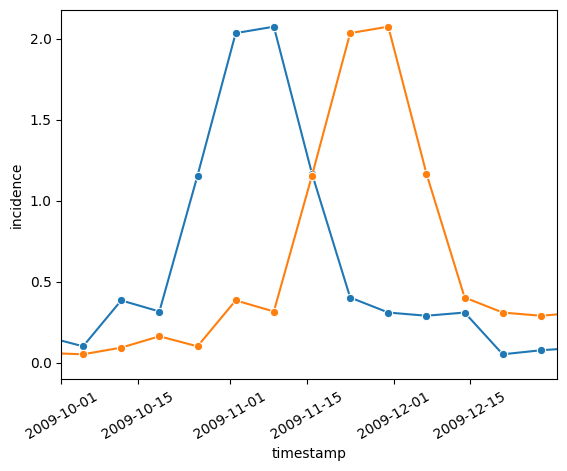

In [40]:
import seaborn as sns

import matplotlib.pyplot as plt

sns.lineplot(df_node, x ='timestamp', y ='incidence', marker = 'o')
sns.lineplot(df_node, x ='timestamp', y ='incidence_lag3', marker = 'o')
plt.xlim(pd.Timestamp('2009-10-01'), pd.Timestamp('2009-12-31'))
plt.xticks(rotation=30)

['incidence_lag3', 'incidence_lag4', 'incidence_lag5', 'incidence_lag6']

In [41]:
epidata_loader_basis.data['final']

,timestamp,node,timestamp_sin,timestamp_cos,incidence_lag3,incidence_lag4,incidence_lag5,incidence_lag6,incidence_h0,incidence_h1,incidence_h2,incidence_h3,train,val,test
0,2006-05-08,0,0.748511,-0.663123,0.000000,0.000000,0.297360,0.654130,0.00000,0.0,0.0,0.0,True,False,False
1,2006-05-08,1,0.748511,-0.663123,0.081556,0.119968,0.041609,0.081556,0.00000,0.0,0.0,0.0,True,False,False
2,2006-05-08,2,0.748511,-0.663123,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,True,False,False
3,2006-05-08,3,0.748511,-0.663123,0.000000,0.120721,0.000000,0.000000,0.00000,0.0,0.0,0.0,True,False,False
4,2006-05-08,4,0.748511,-0.663123,0.000000,0.000000,0.000000,0.000000,0.00000,0.0,0.0,0.0,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
293595,2020-05-25,395,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,False,False,True
293596,2020-05-25,396,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,False,False,True
293597,2020-05-25,397,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,0.00000,NaN,NaN,NaN,False,False,True
293598,2020-05-25,398,0.508531,-0.861044,0.000000,0.000000,0.000000,0.000000,0.18805,NaN,NaN,NaN,False,False,True


(array([14518., 14532., 14549., 14563., 14579., 14593.]),
 [Text(14518.0, 0, '2009-10-01'),
  Text(14532.0, 0, '2009-10-15'),
  Text(14549.0, 0, '2009-11-01'),
  Text(14563.0, 0, '2009-11-15'),
  Text(14579.0, 0, '2009-12-01'),
  Text(14593.0, 0, '2009-12-15')])

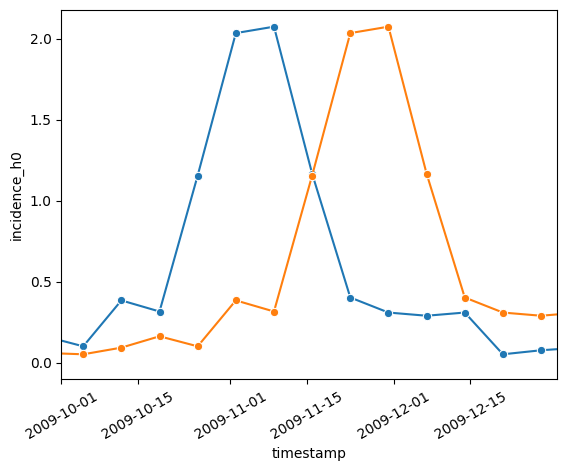

In [43]:
df = epidata_loader_basis.data['final']

df_node = df[df['node'] == 26]

import seaborn as sns

import matplotlib.pyplot as plt

sns.lineplot(df_node, x ='timestamp', y ='incidence_h0', marker = 'o')
sns.lineplot(df_node, x ='timestamp', y ='incidence_lag3', marker = 'o')
plt.xlim(pd.Timestamp('2009-10-01'), pd.Timestamp('2009-12-31'))
plt.xticks(rotation=30)